In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df =pd.read_csv("nyt1.csv")
df.shape

(195438, 5)

In [3]:
df.head()

,Age,Gender,Impressions,Clicks,Signed_In
0,36,0,3.0,0.0,1.0
1,73,1,3.0,0.0,1.0
2,30,0,3.0,0.0,1.0
3,49,1,3.0,0.0,1.0
4,47,1,11.0,0.0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195438 entries, 0 to 195437
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Age          195438 non-null  int64  
 1   Gender       195438 non-null  int64  
 2   Impressions  195437 non-null  float64
 3   Clicks       195437 non-null  float64
 4   Signed_In    195437 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 7.5 MB


In [5]:
df.isnull().sum()

,0
Age,0
Gender,0
Impressions,1
Clicks,1
Signed_In,1


In [6]:
df.duplicated().sum()

np.int64(191286)

In [7]:
df.columns =[col.lower for col in df]

In [8]:
df.describe()

,<built-in method lower of str object at 0x7e3621b2ca80>,<built-in method lower of str object at 0x7e3621b2cae0>,<built-in method lower of str object at 0x7e3621a15230>,<built-in method lower of str object at 0x7e3621b2cb10>,<built-in method lower of str object at 0x7e3621a14cb0>
count,195438.000000,195438.000000,195437.000000,195437.000000,195437.000000
mean,29.372461,0.366725,5.006099,0.092756,0.699013
std,23.598344,0.481912,2.236092,0.310899,0.458688
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,3.000000,0.000000,0.000000
50%,31.000000,0.000000,5.000000,0.000000,1.000000
75%,48.000000,1.000000,6.000000,0.000000,1.000000
max,102.000000,1.000000,20.000000,4.000000,1.000000


In [16]:
df.columns = ['age', 'gender', 'impressions', 'clicks', 'signed_in']

print(df.columns)

Index(['age', 'gender', 'impressions', 'clicks', 'signed_in'], dtype='object')


In [17]:
bins = [0, 18, 25, 35, 45, 55, 65, 110]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df.head()

,age,gender,impressions,clicks,signed_in,age_group
0,36,0,3.0,0.0,1.0,35-44
1,73,1,3.0,0.0,1.0,65+
2,30,0,3.0,0.0,1.0,25-34
3,49,1,3.0,0.0,1.0,45-54
4,47,1,11.0,0.0,1.0,45-54


<Axes: xlabel='age_group', ylabel='count'>

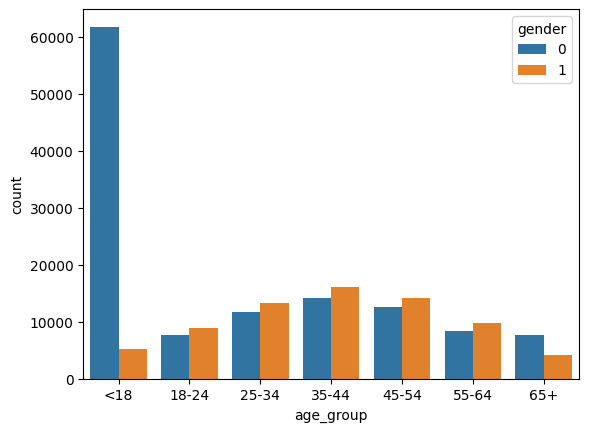

In [18]:
sns.countplot(x = 'age_group' , hue= 'gender' , data =df)

<Axes: xlabel='clicks', ylabel='count'>

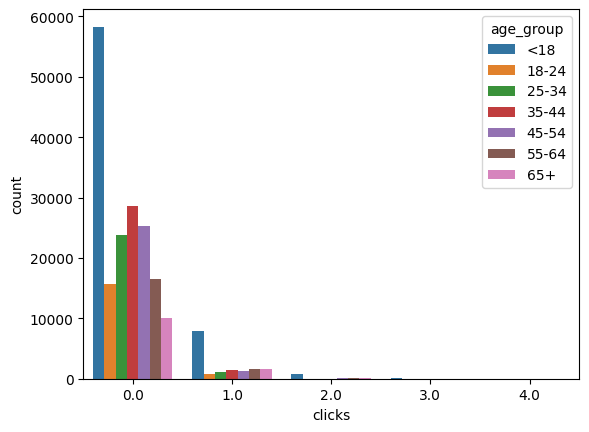

In [19]:
sns.countplot(x = 'clicks' , hue= 'age_group' , data =df)

In [20]:
df[(df['clicks'] > 0)  & (df['impressions'] == 0 )]

,age,gender,impressions,clicks,signed_in,age_group


<Axes: xlabel='impressions', ylabel='Count'>

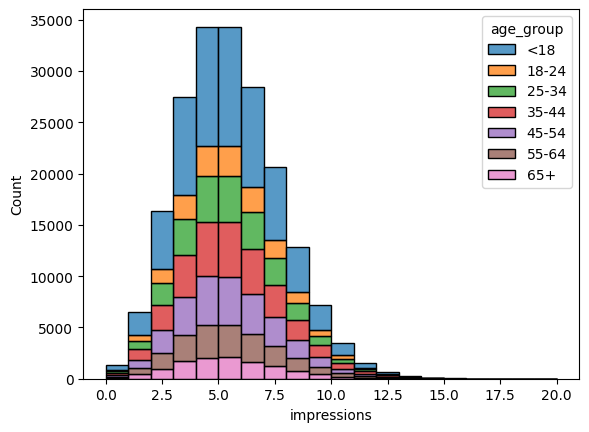

In [22]:
sns.histplot(
    data=df,
    x='impressions',
    hue='age_group',
    stat='count',
    binwidth=1,
    multiple='stack'
)

<Axes: xlabel='age_group', ylabel='impressions'>

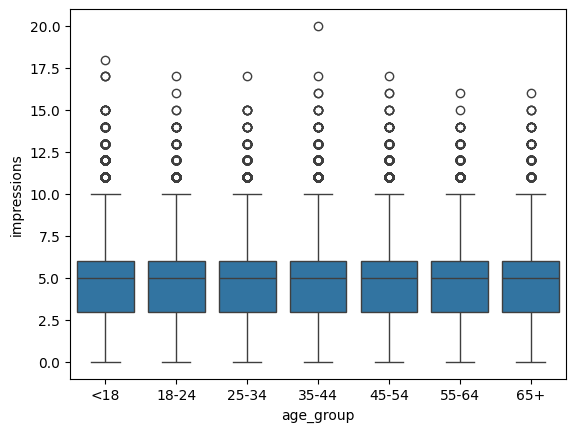

In [23]:
sns.boxplot(y = df['impressions'] , x = df['age_group'])

In [24]:
df['CTR'] = round(df['clicks'] / df['impressions'] , 5)

<Axes: xlabel='age_group', ylabel='CTR'>

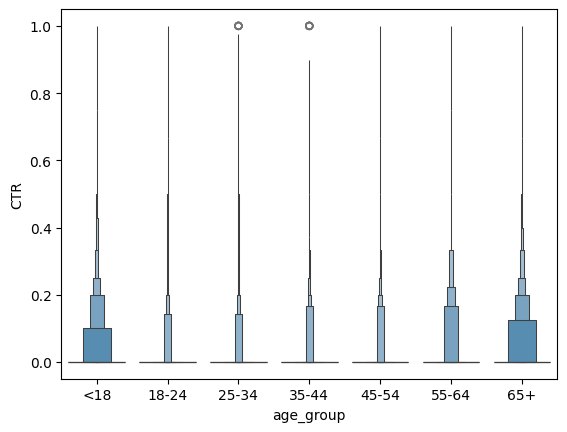

In [25]:
sns.boxenplot(x =df['age_group'] , y =df['CTR'])

In [26]:
bins = [-1 ,0,0.1,0.2,0.4,1]
labels = ['0' , '<10%' , '10%-20%' ,'20%-40%' , '>40%']
df['CTR_group'] = pd.cut(df.CTR , bins , labels =labels)
df.CTR_group.value_counts(normalize =True , sort =True)

,proportion
CTR_group,
0,0.912556
10%-20%,0.054101
20%-40%,0.023601
<10%,0.004997
>40%,0.004745


In [27]:
df_Clicked = df[df['CTR'] > 0]
df_Clicked.head()

,age,gender,impressions,clicks,signed_in,age_group,CTR,CTR_group
5,47,0,11.0,1.0,1.0,45-54,0.09091,<10%
6,0,0,7.0,1.0,0.0,<18,0.14286,10%-20%
10,0,0,8.0,1.0,0.0,<18,0.12500,10%-20%
39,0,0,7.0,2.0,0.0,<18,0.28571,20%-40%
63,0,0,2.0,1.0,0.0,<18,0.50000,>40%


In [28]:
df_Clicked = df[df['CTR'] > 0]
df_Clicked.head()

,age,gender,impressions,clicks,signed_in,age_group,CTR,CTR_group
5,47,0,11.0,1.0,1.0,45-54,0.09091,<10%
6,0,0,7.0,1.0,0.0,<18,0.14286,10%-20%
10,0,0,8.0,1.0,0.0,<18,0.12500,10%-20%
39,0,0,7.0,2.0,0.0,<18,0.28571,20%-40%
63,0,0,2.0,1.0,0.0,<18,0.50000,>40%


In [29]:
df_Clicked.age_group.value_counts(normalize =True)

,proportion
age_group,
<18,0.510458
55-64,0.105462
65+,0.098450
35-44,0.090732
45-54,0.078595
25-34,0.069994
18-24,0.046309


<Axes: xlabel='age_group', ylabel='CTR'>

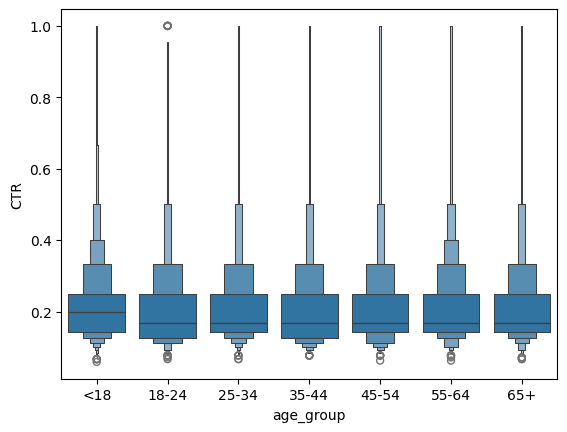

In [30]:
sns.boxenplot(x =df_Clicked['age_group'] , y =df_Clicked['CTR'])

<Axes: xlabel='age_group', ylabel='count'>

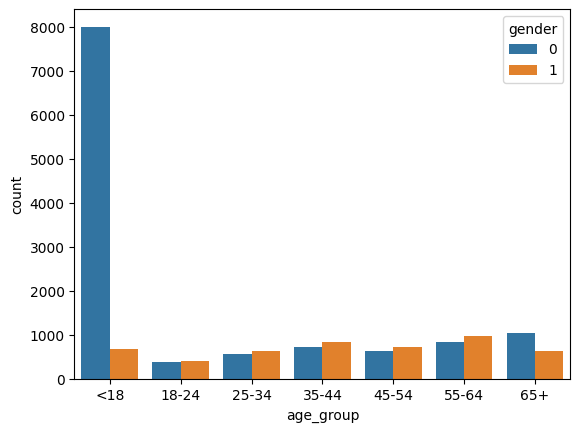

In [31]:
sns.countplot(x= 'age_group' , hue ='gender' , data = df_Clicked)

<Axes: xlabel='age_group', ylabel='count'>

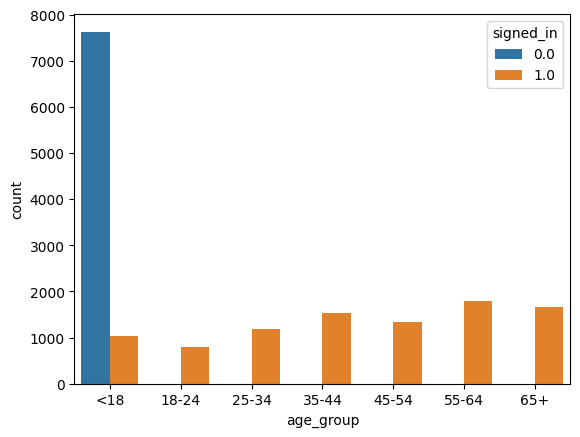

In [32]:
sns.countplot(x= 'age_group' , hue ='signed_in' , data = df_Clicked)